# Spatial Polygon Merging (SPM) Benchmarking

This notebook is used to benchmark the merging performance of the SPM algorithm against other merging methods on images of various sizes. The test dataset is generated by cropping a large image into smaller tiles of different sizes. A fine-tuned model is then used to predict the segmentations in each tile, and fragmented predictions are merged using the SPM algorithm and other methods. The merging performance for each method is then evaluated based on the mAP, precision, recall, and F1-score of the merged polygons compared to the ground truth polygons.

### Benchmark Test Dataset Generation

The WHU Building Dataset provides an uncropped version of the dataset, which contains a large aerial image and its corresponding shapefile of building polygons. The image and shapefile are then passed to the `generate` command of the benchmark module, which crops the image into smaller tiles of different sizes and saves them in the `benchmark_test_set` folder. Below are the links to download the original image and shapefile:

- [Whole Image File](https://gpcv.whu.edu.cn/data/1.the%20whole%20aerial%20image.tif)
- [Shapefile](https://gpcv.whu.edu.cn/data/2.%20The%20shape%20file%20of%20the%20whole%20area.zip)

**Note:** The dataset generated by this code has also been uploaded to Kaggle and can be downloaded from [this link](https://www.kaggle.com/datasets/vincentadiasor/whu-aerial-image-dataset-varying-crops).

In [ ]:
!cd ../ && \
uv run python -m benchmark generate \
"test_images/1.the whole aerial image.tif" \
"test_images/2. The shape file of the whole area/allbuilding.shp" \
benchmark_test_set \
--crop-sizes 3000 5000 10000 20000 50000 100000 \
--stride-ratio 1.0 \
--max-crops 1

[2026-07-13 09:55:48.922470] WARNING - Repairing 4 invalid label geometries (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:65:generate_test_set())
[2026-07-13 09:56:00.102950] INFO - Created 412 records (/media/vince/Backup/Projects/spatial_polygon_merging/.venv/lib/python3.11/site-packages/pyogrio/raw.py:733:write())
[2026-07-13 09:56:00.105718] INFO - Wrote crop benchmark_test_set/crop_5000_0/image.tif with 412 labels (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:100:generate_test_set())
[2026-07-13 09:56:08.371832] INFO - Created 1,505 records (/media/vince/Backup/Projects/spatial_polygon_merging/.venv/lib/python3.11/site-packages/pyogrio/raw.py:733:write())
[2026-07-13 09:56:08.375627] INFO - Wrote crop benchmark_test_set/crop_10000_0/image.tif with 1505 labels (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:100:generate_test_set())
[2026-07-13 09:56:26.490117] INFO - Created 5,250 records (/media/vince/B

### Benchmark Report Generation (CLI)

In [ ]:
!cd ../ && \
uv run python -m benchmark evaluate \
"runs/segment/yolo-seg-whu/weights/best.pt" \
benchmark_test_set \
--device cuda \
--batch-size 4 \
--conf 0.3 \
--tile-size 1500 \
--overlap 0.1 \
--iou 0.5 \
--merge-count 5 \
--output notebooks/results/benchmark_results.csv

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# Load benchmark results
df = pd.read_csv("results/benchmark_results.csv")
df.sort_values(by=["crop_size", "method"], inplace=True, ignore_index=True)
df

,crop,crop_size,method,merge_time_1,merge_time_2,merge_time_3,merge_time_4,merge_time_5,peak_memory_usage_1,peak_memory_usage_2,...,peak_memory_usage_4,peak_memory_usage_5,num_gt,num_pred,mAP,mAP50,mAP75,precision,recall,f1
0,crop_3000_0,3000,sahi_greedy_nmm,0.113981,0.114749,0.114044,0.112535,0.113444,44.527344,44.566406,...,44.417969,44.527344,191,197,0.496135,0.814140,0.585913,0.822335,0.848168,0.835052
1,crop_3000_1,3000,sahi_greedy_nmm,0.178254,0.169266,0.168936,0.169472,0.187799,45.054688,45.007812,...,45.148438,45.117188,174,193,0.561495,0.840519,0.693406,0.792746,0.879310,0.833787
2,crop_3000_2,3000,sahi_greedy_nmm,0.200935,0.199389,0.202680,0.198504,0.198133,46.691406,46.777344,...,46.824219,46.828125,173,218,0.573743,0.846858,0.676906,0.711009,0.895954,0.792839
3,crop_3000_0,3000,sahi_lsnms,6.343702,6.210273,6.267931,6.358796,6.251985,227.359375,227.875000,...,227.867188,227.839844,191,197,0.488549,0.807955,0.592251,0.817259,0.842932,0.829897
4,crop_3000_1,3000,sahi_lsnms,6.399137,6.217787,6.269699,6.261410,6.316893,228.859375,228.750000,...,228.976562,228.742188,174,193,0.542674,0.847505,0.645352,0.797927,0.885057,0.839237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,crop_100000_1,100000,spm_global,15.347055,15.520842,15.231639,15.333839,15.382000,729.449219,729.472656,...,729.855469,729.570312,55580,59319,0.623869,0.886757,0.749298,0.851565,0.908852,0.879277
103,crop_100000_2,100000,spm_global,11.406019,11.324493,11.333195,11.916577,11.873877,565.308594,565.968750,...,565.640625,566.015625,33616,37069,0.617786,0.872413,0.732243,0.810677,0.893949,0.850279
104,crop_100000_0,100000,spm_seam_only,14.321311,14.260297,14.077173,14.295606,14.307927,677.257812,677.597656,...,678.156250,676.894531,56254,61470,0.611319,0.883217,0.727240,0.827428,0.904149,0.864089
105,crop_100000_1,100000,spm_seam_only,13.812713,13.988409,14.027608,14.028421,13.831616,725.410156,724.917969,...,724.832031,726.500000,55580,61049,0.630618,0.895646,0.757858,0.834674,0.916805,0.873814


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   crop                      107 non-null    str    
 1   crop_size                 107 non-null    int64  
 2   method                    107 non-null    str    
 3   num_gt                    107 non-null    int64  
 4   num_pred                  107 non-null    int64  
 5   mAP                       107 non-null    float64
 6   mAP50                     107 non-null    float64
 7   mAP75                     107 non-null    float64
 8   precision                 107 non-null    float64
 9   recall                    107 non-null    float64
 10  f1                        107 non-null    float64
 11  median_merge_time         107 non-null    float64
 12  median_peak_memory_usage  107 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 11.0 KB


In [20]:
# Take the median of the merge_time and peak_memory_usage for each run per crop
df["median_merge_time"] = df[[col for col in df.columns if col.startswith("merge_time_")]].median(axis=1)
df["median_peak_memory_usage"] = df[[col for col in df.columns if col.startswith("peak_memory_usage_")]].median(axis=1)
# Drop the individual merge_time and peak_memory_usage columns
df.drop(columns=[col for col in df.columns if col.startswith("merge_time_") or col.startswith("peak_memory_usage_")], inplace=True)
df

,crop,crop_size,method,num_gt,num_pred,mAP,mAP50,mAP75,precision,recall,f1,median_merge_time,median_peak_memory_usage
0,crop_3000_0,3000,sahi_greedy_nmm,191,197,0.496135,0.814140,0.585913,0.822335,0.848168,0.835052,0.113981,44.527344
1,crop_3000_1,3000,sahi_greedy_nmm,174,193,0.561495,0.840519,0.693406,0.792746,0.879310,0.833787,0.169472,45.117188
2,crop_3000_2,3000,sahi_greedy_nmm,173,218,0.573743,0.846858,0.676906,0.711009,0.895954,0.792839,0.199389,46.777344
3,crop_3000_0,3000,sahi_lsnms,191,197,0.488549,0.807955,0.592251,0.817259,0.842932,0.829897,6.267931,227.867188
4,crop_3000_1,3000,sahi_lsnms,174,193,0.542674,0.847505,0.645352,0.797927,0.885057,0.839237,6.269699,228.859375
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,crop_100000_1,100000,spm_global,55580,59319,0.623869,0.886757,0.749298,0.851565,0.908852,0.879277,15.347055,729.472656
103,crop_100000_2,100000,spm_global,33616,37069,0.617786,0.872413,0.732243,0.810677,0.893949,0.850279,11.406019,565.968750
104,crop_100000_0,100000,spm_seam_only,56254,61470,0.611319,0.883217,0.727240,0.827428,0.904149,0.864089,14.295606,677.597656
105,crop_100000_1,100000,spm_seam_only,55580,61049,0.630618,0.895646,0.757858,0.834674,0.916805,0.873814,13.988409,724.968750


In [25]:
mt_and_pm_columns = [col for col in df.columns if col.startswith("median_")]
metrics_columns = df.columns.difference(["crop_size", "method", "crop"] + mt_and_pm_columns)  # Exclude the first three columns and merge_time/peak_memory columns

# Aggregate merge_time and peak_memory_usage columns by median, min, and max for each crop_size and method
result_agg = {f"{col}": (col, "median") for col in mt_and_pm_columns}
result_agg.update({f"{col.replace('median_', 'min_')}": (col, "min") for col in mt_and_pm_columns})
result_agg.update({f"{col.replace('median_', 'max_')}": (col, "max") for col in mt_and_pm_columns})

# Aggregate metrics columns by mean and std for each crop_size and method
result_agg.update({f"{col}_mean": (col, "mean") for col in metrics_columns})
result_agg.update({f"{col}_std": (col, "std") for col in metrics_columns})

grouped_df = df.groupby(["crop_size", "method"]).agg(**result_agg).reset_index()
grouped_df


,crop_size,method,median_merge_time,median_peak_memory_usage,min_merge_time,min_peak_memory_usage,max_merge_time,max_peak_memory_usage,f1_mean,mAP_mean,...,precision_mean,recall_mean,f1_std,mAP_std,mAP50_std,mAP75_std,num_gt_std,num_pred_std,precision_std,recall_std
0,3000,sahi_greedy_nmm,0.169472,45.117188,0.113981,44.527344,0.199389,46.777344,0.820559,0.543791,...,0.775363,0.874477,0.024015,0.041723,0.017351,0.057889,10.115994,13.428825,0.057663,0.024257
1,3000,sahi_lsnms,6.269699,228.859375,6.267931,227.867188,6.279937,228.945312,0.820658,0.534899,...,0.775399,0.874648,0.024540,0.042993,0.022649,0.045244,10.115994,13.428825,0.056594,0.028002
2,3000,sahi_nmm,0.176731,45.191406,0.116096,44.558594,0.200464,46.808594,0.822801,0.543993,...,0.779529,0.874477,0.025955,0.041826,0.017535,0.058040,10.115994,14.364308,0.060692,0.024257
3,3000,sahi_nms,0.006505,44.742188,0.006324,43.984375,0.007890,46.410156,0.820658,0.534899,...,0.775399,0.874648,0.024540,0.042993,0.022649,0.045244,10.115994,13.428825,0.056594,0.028002
4,3000,smm,45.390770,5209.070312,40.453109,5085.648438,51.097052,5896.695312,0.848718,0.544573,...,0.826406,0.874477,0.020378,0.046665,0.024442,0.075851,10.115994,11.532563,0.051178,0.024257
5,3000,spm_global,0.087469,3.042969,0.047760,2.363281,0.097970,3.273438,0.863092,0.561378,...,0.862408,0.865206,0.022564,0.049850,0.023958,0.063296,10.115994,8.544004,0.046986,0.023827
6,3000,spm_seam_only,0.086196,3.023438,0.047506,2.328125,0.094962,3.191406,0.859922,0.562303,...,0.856219,0.865206,0.023528,0.050131,0.023750,0.063439,10.115994,9.018500,0.048964,0.023827
7,5000,sahi_greedy_nmm,0.206055,55.589844,0.185493,54.550781,0.222621,58.511719,0.826308,0.577387,...,0.752762,0.918200,0.031793,0.025813,0.004300,0.052133,4.163332,38.734137,0.057344,0.007768
8,5000,sahi_lsnms,6.431319,225.851562,6.328005,225.015625,6.803275,226.500000,0.820996,0.546778,...,0.747744,0.912576,0.023818,0.045827,0.025228,0.079481,4.163332,38.734137,0.049994,0.016796
9,5000,sahi_nmm,0.206616,55.082031,0.191772,54.378906,0.220073,57.953125,0.828060,0.577677,...,0.756386,0.917399,0.032672,0.025376,0.007435,0.051434,4.163332,40.595566,0.059911,0.008913


In [46]:
# Mean quality metrics
mean_std_metrics_df = grouped_df[["crop_size", "method"] + [col for col in grouped_df.columns if col.endswith("_mean") or col.endswith("_std")]]
mean_std_metrics_df = mean_std_metrics_df[["crop_size", "method"] + sorted([col for col in mean_std_metrics_df.columns if col not in ["crop_size", "method"]])]
mean_std_metrics_df.drop(columns=[col for col in mean_std_metrics_df.columns if col.startswith("num_")], inplace=True)
mean_std_metrics_df.to_csv("results/mean_std_metrics.csv", index=False)
mean_std_metrics_df

,crop_size,method,f1_mean,f1_std,mAP50_mean,mAP50_std,mAP75_mean,mAP75_std,mAP_mean,mAP_std,precision_mean,precision_std,recall_mean,recall_std
0,3000,sahi_greedy_nmm,0.820559,0.024015,0.833839,0.017351,0.652075,0.057889,0.543791,0.041723,0.775363,0.057663,0.874477,0.024257
1,3000,sahi_lsnms,0.820658,0.024540,0.834106,0.022649,0.639952,0.045244,0.534899,0.042993,0.775399,0.056594,0.874648,0.028002
2,3000,sahi_nmm,0.822801,0.025955,0.834272,0.017535,0.652244,0.058040,0.543993,0.041826,0.779529,0.060692,0.874477,0.024257
3,3000,sahi_nms,0.820658,0.024540,0.834106,0.022649,0.639952,0.045244,0.534899,0.042993,0.775399,0.056594,0.874648,0.028002
4,3000,smm,0.848718,0.020378,0.848114,0.024442,0.641355,0.075851,0.544573,0.046665,0.826406,0.051178,0.874477,0.024257
5,3000,spm_global,0.863092,0.022564,0.845847,0.023958,0.666968,0.063296,0.561378,0.049850,0.862408,0.046986,0.865206,0.023827
6,3000,spm_seam_only,0.859922,0.023528,0.845968,0.023750,0.667372,0.063439,0.562303,0.050131,0.856219,0.048964,0.865206,0.023827
7,5000,sahi_greedy_nmm,0.826308,0.031793,0.869283,0.004300,0.674321,0.052133,0.577387,0.025813,0.752762,0.057344,0.918200,0.007768
8,5000,sahi_lsnms,0.820996,0.023818,0.851193,0.025228,0.624995,0.079481,0.546778,0.045827,0.747744,0.049994,0.912576,0.016796
9,5000,sahi_nmm,0.828060,0.032672,0.867866,0.007435,0.675100,0.051434,0.577677,0.025376,0.756386,0.059911,0.917399,0.008913


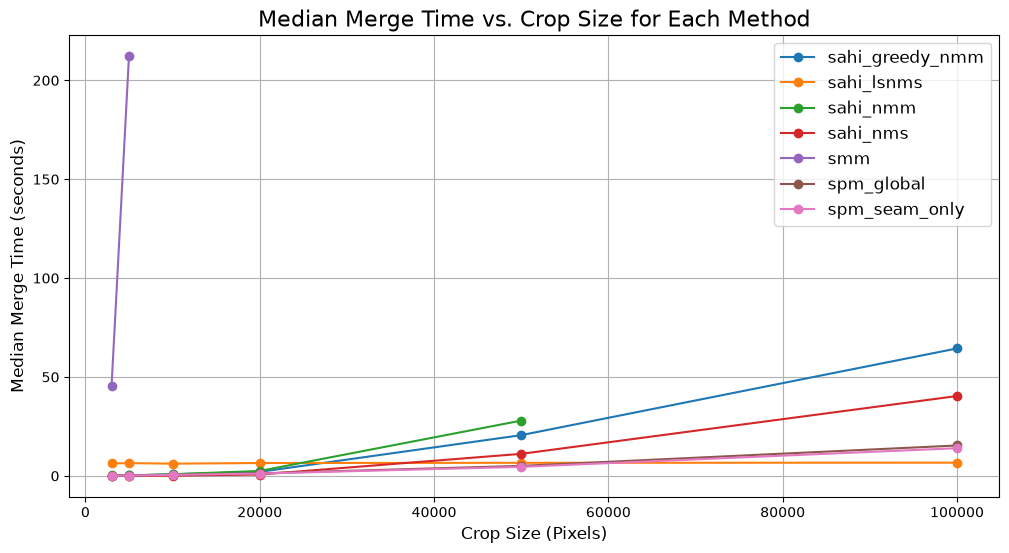

In [27]:
# Visualize median merge_time vs. crop_size for each method
plt.figure(figsize=(12, 6))
for method in grouped_df["method"].unique():
    method_data = grouped_df[grouped_df["method"] == method]
    plt.plot(method_data["crop_size"], method_data["median_merge_time"], marker='o', label=method)
plt.title("Median Merge Time vs. Crop Size for Each Method", fontsize=16)
plt.xlabel("Crop Size (Pixels)", fontsize=12)
plt.ylabel("Median Merge Time (seconds)", fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.savefig("results/merge_time_vs_crop_size.png")
plt.show()

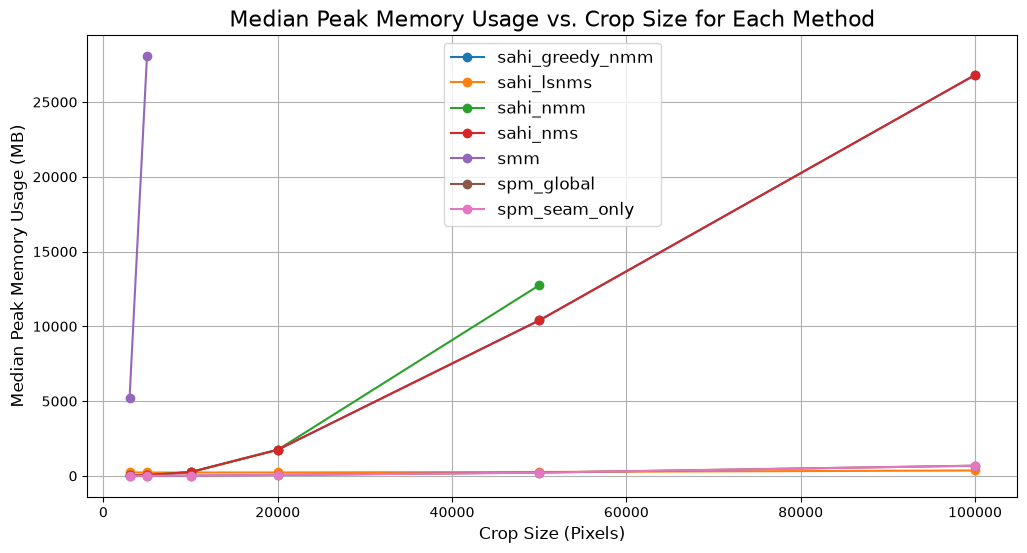

In [28]:
# Visualize median peak_memory_usage vs. number of polygons for each method
plt.figure(figsize=(12, 6))
for method in grouped_df["method"].unique():
    method_data = grouped_df[grouped_df["method"] == method]
    plt.plot(method_data["crop_size"], method_data["median_peak_memory_usage"], marker='o', label=method)
plt.title("Median Peak Memory Usage vs. Crop Size for Each Method", fontsize=16)
plt.xlabel("Crop Size (Pixels)", fontsize=12)
plt.ylabel("Median Peak Memory Usage (MB)", fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.savefig("results/peak_memory_usage_vs_crop_size.png")
plt.show()

In [30]:
# Get the metrics for each method at the 5000 crop size (where all methods have results)
df_metrics_5000 = grouped_df[grouped_df["crop_size"] == 5000][["method","mAP_mean", "mAP50_mean", "mAP75_mean", "precision_mean", "recall_mean", "f1_mean"]]
df_metrics_5000

,method,mAP_mean,mAP50_mean,mAP75_mean,precision_mean,recall_mean,f1_mean
7,sahi_greedy_nmm,0.577387,0.869283,0.674321,0.752762,0.918200,0.826308
8,sahi_lsnms,0.546778,0.851193,0.624995,0.747744,0.912576,0.820996
9,sahi_nmm,0.577677,0.867866,0.675100,0.756386,0.917399,0.828060
10,sahi_nms,0.546778,0.851193,0.624995,0.747744,0.912576,0.820996
11,smm,0.576462,0.890405,0.666426,0.820009,0.910891,0.861903
12,spm_global,0.587295,0.879310,0.688769,0.859027,0.894709,0.875193
13,spm_seam_only,0.589863,0.882721,0.691964,0.855064,0.897953,0.874625


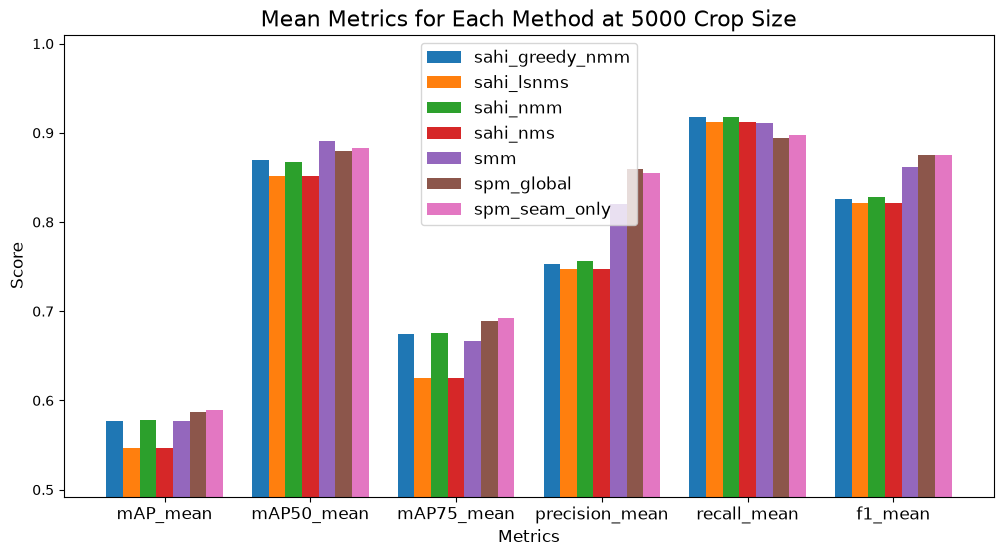

In [33]:
categories = df_metrics_5000.columns[1:]
n = len(df_metrics_5000)
x = np.arange(len(categories))
# print(f"Categories: {categories}, Number of methods: {n}, X positions: {x}")
width = 0.8 / n

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(df_metrics_5000.iterrows()):
    offset = (i - (n - 1) / 2) * width
    # print(f"Row: {row['method']}, Offset: {offset}, Width: {width}, X positions: {x + offset}")
    ax.bar(x+offset, row[categories], width=width, label=row["method"], align='center', bottom=None)

ax.set_xticks(x)
ax.set_ylim(df_metrics_5000[categories].min().values.min() * 0.9, df_metrics_5000[categories].max().values.max() * 1.1)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(fontsize=12)
ax.set_title("Mean Metrics for Each Method at 5000 Crop Size", fontsize=16)
ax.set_xlabel("Metrics", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
plt.savefig("results/metrics_for_each_method_at_5000_crop_size.png")

## Compare SPM Merge Quality Over Varying Values of Proximity Threshold and BFS Depth Threshold

The SPM algorithm have two main parameters that determine the merging quality: the proximity threshold and the BFS depth threshold. To evaluate how these values affect the merging qualiuty, we will run a benchmark test on an unmerged prediction of an image of a fix crop size of 50000 pixels, and vary the proximity threshold and BFS depth threshold values. The benchmark report will be generated in the `results` folder.

In [3]:
import sys

sys.path.append("../")

In [4]:
from dataclasses import asdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from benchmark.eval import evaluate_prediction
from benchmark.methods import merge_spm
from benchmark.runner import _write_csv
from spm.config import SPMConfig, ModelConfig
from spm.models.yolo import YOLOModel

In [ ]:
test_image_path = "../benchmark_test_set/crop_50000_0/image.tif"
test_label_path = "../benchmark_test_set/crop_50000_0/labels.gpkg"

report_path = Path("results/benchmark_prox_bfs_report.csv")

In [6]:
config = ModelConfig(
    model_path="../runs/segment/yolo-seg-whu/weights/best.pt",
    device="cuda",
    batch_size=4,
    confidence_threshold=0.3,
    tile_size=1500,
    overlap=0.1,
    iou_threshold=0.5
)

model = YOLOModel(config)
unmerged = model(test_image_path, merge=False)

[2026-07-25 15:51:36.797563] INFO - Performing prediction on image: ../benchmark_test_set/crop_50000_0/image.tif (width: 50000, height: 50000) (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/models/yolo.py:85:predict())
[2026-07-25 15:53:09.104351] INFO - Total tiles processed: 1369 (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/models/yolo.py:184:predict())


In [7]:
prox_values = [1.0, 2.0, 4.0, 8.0, 16.0]
bfs_depth_values = [1, 2, 3, 4, 5]

In [8]:
rows = []
for prox in prox_values:
    for bfs_depth in bfs_depth_values:
        spm_config = SPMConfig(tau_dist=prox, rho_chain=bfs_depth)
        merged, _ = merge_spm(unmerged, spm_config)
        metrics = evaluate_prediction(merged, test_label_path)
        rows.append({
            "proximity_threshold": prox,
            "bfs_depth_threshold": bfs_depth,
            **asdict(metrics)
            })
        
_write_csv(rows, report_path)

[2026-07-25 15:53:09.127257] INFO - Running SPM with config: SPMConfig(tau_dist=1.0, rho_chain=1), merge_only_seam=False (/media/vince/Backup/Projects/spatial_polygon_merging/notebooks/../benchmark/methods.py:201:merge_spm())
[2026-07-25 15:53:09.127958] INFO - Indexing polygons for merging (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/merging/spm.py:21:index())
[2026-07-25 15:53:23.357896] INFO - Running SPM with config: SPMConfig(tau_dist=1.0, rho_chain=2), merge_only_seam=False (/media/vince/Backup/Projects/spatial_polygon_merging/notebooks/../benchmark/methods.py:201:merge_spm())
[2026-07-25 15:53:23.358613] INFO - Indexing polygons for merging (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/merging/spm.py:21:index())
[2026-07-25 15:53:35.463511] INFO - Running SPM with config: SPMConfig(tau_dist=1.0, rho_chain=3), merge_only_seam=False (/media/vince/Backup/Projects/spatial_polygon_merging/notebooks/../benchmark/methods.py:201:merge_spm())
[2026-07-25 

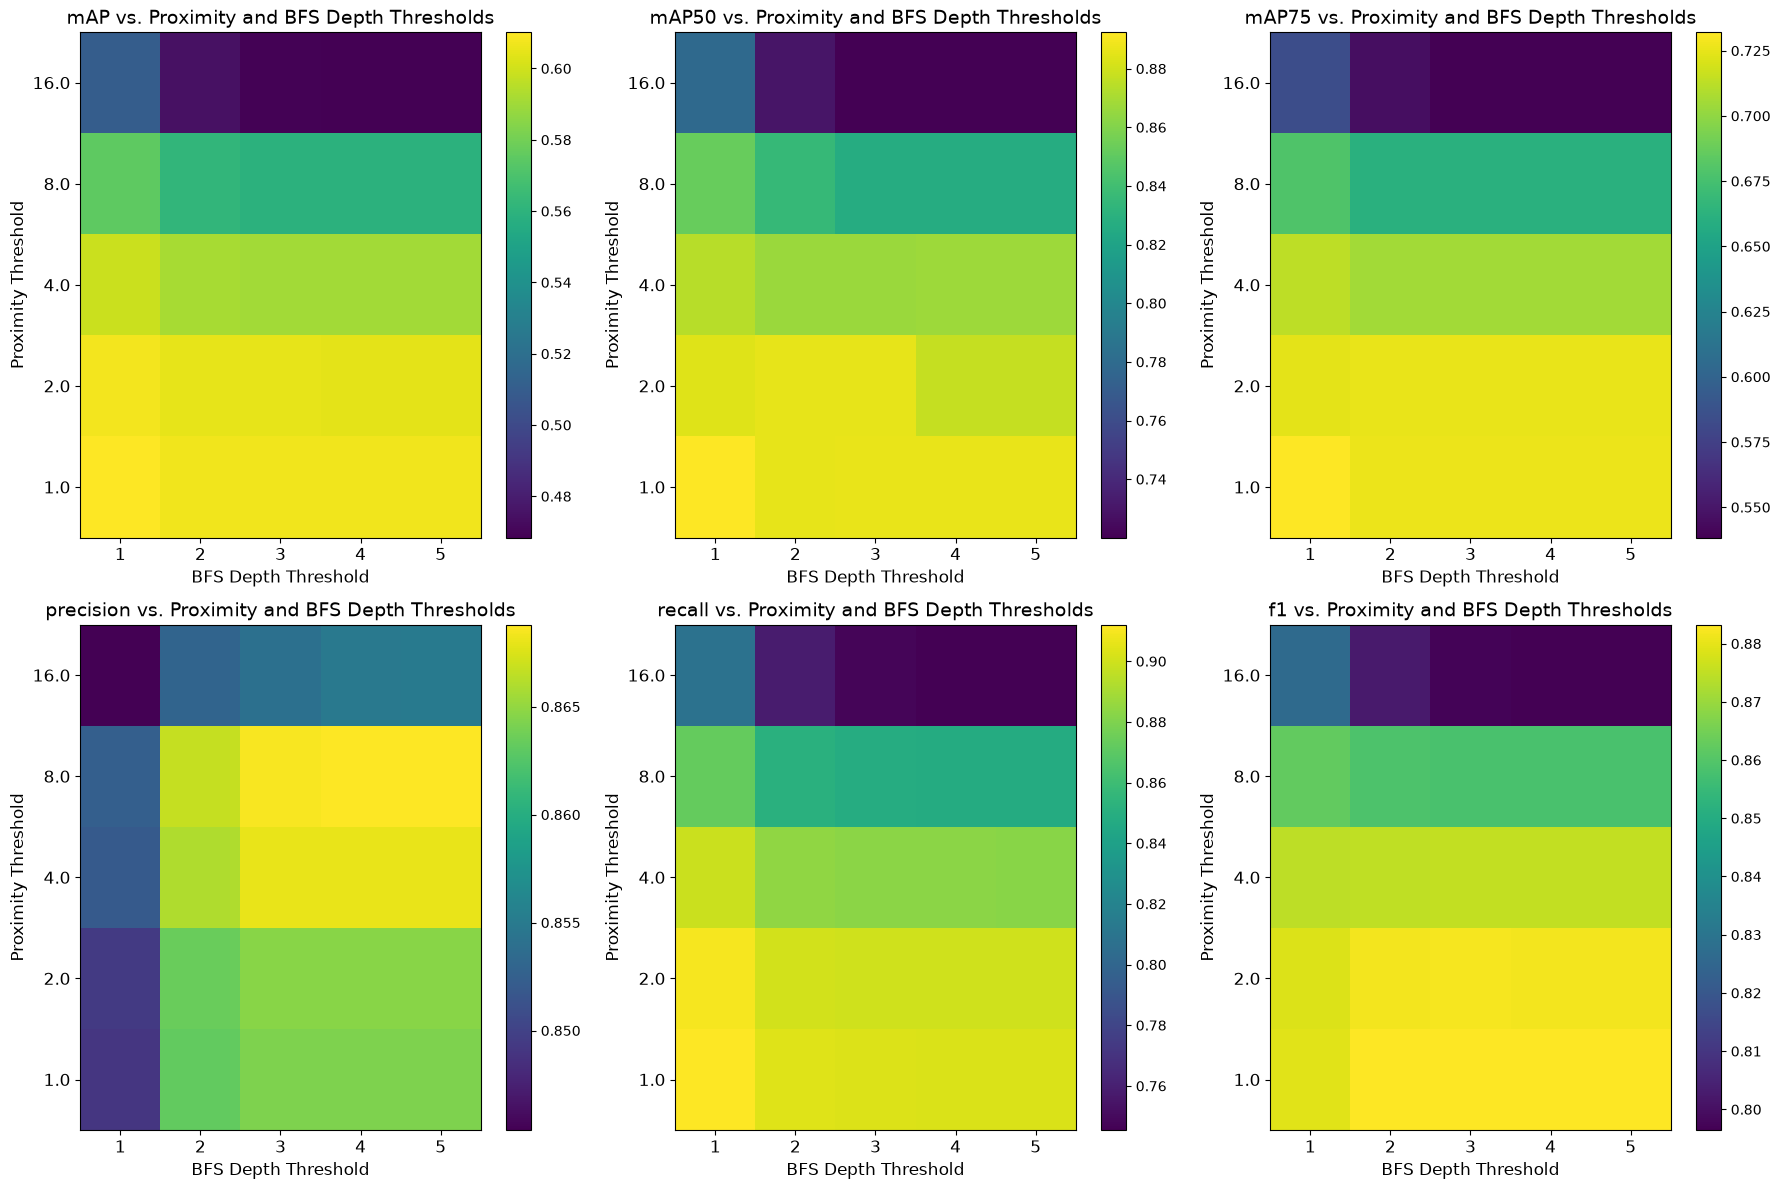

In [9]:
# Visualize the metrics for varying proximity and BFS depth thresholds
df = pd.read_csv(report_path)

fig, ax = plt.subplots(2, 3, figsize=(18, 12))
metrics = ["mAP", "mAP50", "mAP75", "precision", "recall", "f1"]
for i, metric in enumerate(metrics):
    row = i // 3
    col = i % 3
    pivot_table = df.pivot(index="proximity_threshold", columns="bfs_depth_threshold", values=metric)
    cax = ax[row, col].imshow(pivot_table, cmap='viridis', aspect='auto', origin='lower')
    ax[row, col].set_title(f"{metric} vs. Proximity and BFS Depth Thresholds", fontsize=14)
    ax[row, col].set_xlabel("BFS Depth Threshold", fontsize=12)
    ax[row, col].set_ylabel("Proximity Threshold", fontsize=12)
    ax[row, col].set_xticks(range(len(bfs_depth_values)))
    ax[row, col].set_xticklabels(bfs_depth_values, fontsize=12)
    ax[row, col].set_yticks(range(len(prox_values)))
    ax[row, col].set_yticklabels(prox_values, fontsize=12)
    fig.colorbar(cax, ax=ax[row, col], orientation='vertical')
plt.tight_layout()
plt.savefig("results4/metrics_vs_prox_bfs_depth_thresholds.png")